# Test the number of clusters hyperparameter for the IVF Flat index

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from index_FlatL2 import IndexFlatL2
from index_IVFFlat import IndexIVFFlat
from index_PQ import IndexPQ

In [16]:
N_QUERIES = 20
K = 5
cluster_tests = [10, 100, 1000, 10000]

# define the test set
test_embeddings = np.load("100K_embeddings/subset_7/embeddings.npy")
# shuffle the dataset
np.random.shuffle(test_embeddings)
test_embeddings = test_embeddings[:N_QUERIES,:]

# define the number of chunks
N_CHUNKS = np.load("100K_embeddings/subset_0/embeddings.npy").shape[0]
N_CHUNKS

482414

In [20]:
print(f"Theoretical optimal number of clusters for runtime: {np.sqrt(N_CHUNKS)}")

Theoretical optimal number of clusters for runtime: 694.5602925592565


In [3]:
# create the flat index
flat = IndexFlatL2()
flat.create("100K_embeddings/subset_0", "indexes/hyperparameter_tests/flat")

# get the results
flat_results = [flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]
flat_time = np.mean([x['Time'] for x in flat_results])
flat_costs = np.array([np.sum([x['Score'] for x in query['Content']]) for query in flat_results])

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2963951.661 KB
Time to create index: 24.6352 seconds


In [4]:
"""Compute the sum of distances between the query and the top K search results for an index"""
def get_cost(query_emb, query_result):
    cost = [np.sum((query_emb - flat.embed_text(x['Content']))**2) for x in query_result['Content']]
    return np.sum(cost)

In [ ]:
for n_list in cluster_tests: 
    # create the IVF flat index
    ivf_flat = IndexIVFFlat()
    ivf_flat.create(f"100K_embeddings/subset_0", f"indexes/hyperparameter_tests/ivf_flat{n_list}", n_list)

In [18]:
ivf_flat_times = []
ivf_flat_scores = []
costs = []

for n_list in cluster_tests: 
    # read the IVF flat index
    ivf_flat = IndexIVFFlat()
    ivf_flat.read(f"indexes/hyperparameter_tests/ivf_flat{n_list}")

    ivf_flat_results = [ivf_flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]
    ivf_flat_times.append(np.mean([x['Time'] for x in ivf_flat_results]))
    ivf_flat_costs = np.array([get_cost(test_embeddings[i], ivf_flat_results[i]) for i in range(N_QUERIES)])
    costs.append(ivf_flat_costs)
    ivf_flat_scores.append(np.mean(ivf_flat_costs - flat_costs))

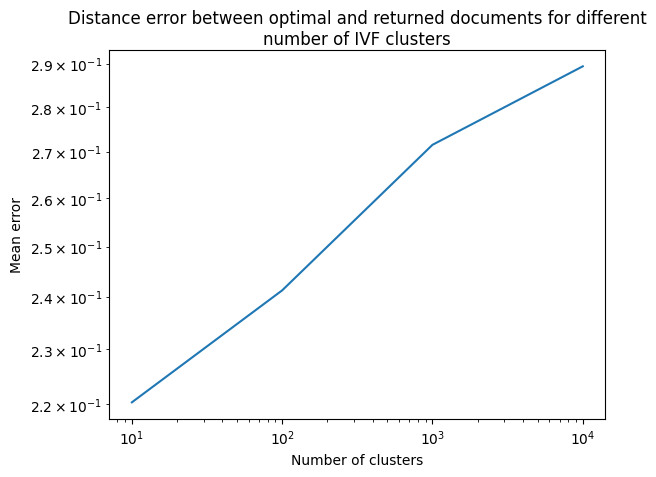

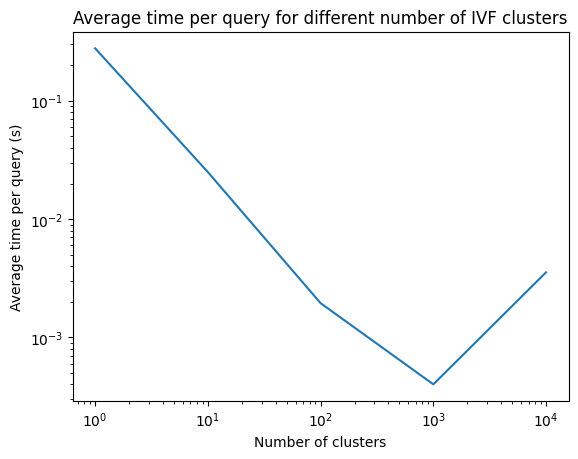

In [27]:
# plt.semilogx([1] + cluster_tests, [0] + ivf_flat_scores)
plt.loglog(cluster_tests, ivf_flat_scores)
plt.title("Distance error between optimal and returned documents for different number of IVF clusters", wrap=True)
plt.xlabel("Number of clusters")
plt.ylabel("Mean error")
plt.show()

plt.loglog([1] + cluster_tests, [flat_time] + ivf_flat_times)
plt.title("Average time per query for different number of IVF clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Average time per query (s)")
plt.show()

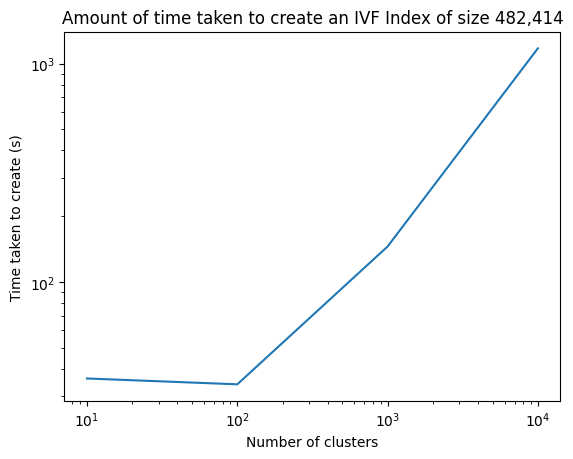

In [5]:
cluster_tests = [10, 100, 1000, 10000]
time_taken = [36.1295, 33.9691, 145.3125, 1174.5363]

plt.loglog(cluster_tests, time_taken)
plt.title("Amount of time taken to create an IVF Index of size 482,414", wrap=True)
plt.xlabel("Number of clusters")
plt.ylabel("Time taken to create (s)")
plt.show()